# EE-411 — Fundamentals of Inference and Learning
## Exercise Session 1 — Resampling and Statistical Inference

**Learning objectives**
- Manipulate and summarize data with pandas.
- Compare statistics between populations.
- Implement and interpret a one-sided permutation test.
- Use bootstrap resampling to estimate uncertainty in sample statistics.
- Apply these methods independently to the Titanic dataset.

**Prerequisites:** introductory Python; pandas, NumPy and Matplotlib.

Run this notebook from the TP1 folder, with `audit_of_political_engagement_14_2017.tab` and `titanic.csv` alongside it. On a hosted notebook service, upload both files to the working directory. The Brexit section contains worked examples and a few tasks; the Titanic section asks you to apply the same methods. Complete cells marked `TODO` in order.

## Part 1 — Guided example: Brexit ages

We introduce permutation testing through an analysis of the Brexit referendum, following [this Brexit age analysis](https://matthew-brett.github.io/les-pilot/brexit_ages.html). This also provides an opportunity to review pandas, a package for data manipulation that we will use throughout the course.

The Hansard Society survey interviewed 1771 people about the 2016 referendum. The local data file comes from the [Audit of Political Engagement 14](https://datacatalogue.ukdataservice.ac.uk/studies/study/8183).

In the sample, the average age of the Brexiteers is higher than that of the Remainers. Is this evidence of a population difference, or could it be explained by sampling variation?

We consider a **one-sided** hypothesis test:

$$H_0: \mu_B = \mu_R, \qquad H_1: \mu_B > \mu_R,$$

where $B$ denotes Brexiteers, $R$ denotes Remainers, and $\mu$ denotes the population mean age. Our statistic is

$$T_{\mathrm{obs}} = \operatorname{mean}(B)-\operatorname{mean}(R).$$

(under the nulle hypothesis) For the permutation test, under $H_0$ we assume that voting labels are exchangeable with respect to age: relabelling the pooled ages does not change their joint distribution. This motivates randomly permuting the labels while preserving the two group sizes. Equality of means alone does not guarantee exchangeability; this is the additional assumption used by this simple test.

Let's proceed in small steps, starting with pandas.

### Worked example — Data manipulation with pandas

In [2]:
# Let's import the package 
import pandas as pd

In [3]:
# Read the local tab-separated file into a DataFrame.
data_raw = pd.read_csv('audit_of_political_engagement_14_2017.tab', sep='\t')

Pandas represents tabular data as a **DataFrame**. Displaying it gives:

In [4]:
data_raw

,cu041,cu042,cu043,cu044,cu045,cu046,cu047,cu048,cu049,cu0410,...,intten,cx_971_980,serial,week,wts,numage,weight0,sgrade_grp,age_grp,region2
0,0,0,0,0,1,1,0,0,0,0,...,-1,3.41659,1399,648,3.41659,37,3.41659,1,4,3
1,0,0,0,0,0,0,0,0,0,1,...,-1,2.68198,1733,648,2.68198,55,2.68198,2,6,3
2,0,0,0,0,1,0,0,0,0,0,...,-1,0.79379,1736,648,0.79379,71,0.79379,2,7,4
3,0,0,0,0,1,0,1,0,0,0,...,-1,1.40580,1737,648,1.40580,37,1.40580,1,4,4
4,0,0,0,1,1,0,1,0,0,0,...,-1,0.89475,1738,648,0.89475,42,0.89475,2,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1766,0,0,0,0,0,0,0,0,0,0,...,9,0.44339,3423,649,0.44339,39,0.44339,1,4,4
1767,0,0,0,0,0,0,0,0,0,0,...,9,0.44086,3425,649,0.44086,20,0.44086,3,2,4
1768,0,0,0,0,0,0,0,0,0,0,...,9,0.32590,3426,649,0.32590,31,0.32590,3,3,4
1769,0,0,0,0,0,0,0,0,0,0,...,9,0.66970,3427,649,0.66970,47,0.66970,4,5,4


Typically, one would start by looking the first lines, using:

In [5]:
data_raw.head()

,cu041,cu042,cu043,cu044,cu045,cu046,cu047,cu048,cu049,cu0410,...,intten,cx_971_980,serial,week,wts,numage,weight0,sgrade_grp,age_grp,region2
0,0,0,0,0,1,1,0,0,0,0,...,-1,3.41659,1399,648,3.41659,37,3.41659,1,4,3
1,0,0,0,0,0,0,0,0,0,1,...,-1,2.68198,1733,648,2.68198,55,2.68198,2,6,3
2,0,0,0,0,1,0,0,0,0,0,...,-1,0.79379,1736,648,0.79379,71,0.79379,2,7,4
3,0,0,0,0,1,0,1,0,0,0,...,-1,1.40580,1737,648,1.40580,37,1.40580,1,4,4
4,0,0,0,1,1,0,1,0,0,0,...,-1,0.89475,1738,648,0.89475,42,0.89475,2,4,4


Another useful pandas tool is `describe`, that is used to generate descriptive statistics of the data in a Pandas DataFrame

In [6]:
data_raw.describe()

,cu041,cu042,cu043,cu044,cu045,cu046,cu047,cu048,cu049,cu0410,...,intten,cx_971_980,serial,week,wts,numage,weight0,sgrade_grp,age_grp,region2
count,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,...,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000,1771.000000
mean,0.119706,0.038396,0.063241,0.122530,0.231508,0.189723,0.104461,0.040090,0.058159,0.041784,...,1.102767,1.000000,2591.394692,648.252964,1.000000,46.421231,1.000000,2.429701,4.670243,4.006211
std,0.324710,0.192206,0.243465,0.327989,0.421915,0.392193,0.305944,0.196227,0.234110,0.200152,...,3.969324,0.772496,576.149480,0.434834,0.772496,18.625718,0.772496,1.101616,1.848105,1.626568
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,0.068530,1012.000000,648.000000,0.068530,0.000000,0.068530,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,0.483895,2183.000000,648.000000,0.483895,31.000000,0.483895,2.000000,3.000000,3.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,0.801870,2624.000000,648.000000,0.801870,45.000000,0.801870,2.000000,5.000000,4.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,1.279665,3067.500000,649.000000,1.279665,61.500000,1.279665,3.000000,6.000000,5.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,10.000000,6.669790,3495.000000,649.000000,6.669790,92.000000,6.669790,4.000000,8.000000,6.000000


Each column is a **feature**, and each row represents one respondent. We need only `numage` (age) and `cut15` (referendum vote). Select these columns and give them descriptive names.

In [7]:
# Feature selection
data = data_raw[['numage', 'cut15']]
# Rename columns
data.columns = ['age', 'vote']

The possible answer to the question - How did you vote on the question ‘Should the United Kingdom remain a member of the European Union or leave the European Union’?” - are encoded through $\textbf{labels}$, i.e. a number going from 1 to 6 encoding what was the answer:

Value = 1.0 $\qquad$ Label = Remain a member of the European Union

Value = 2.0 $\qquad$   Label = Leave the European Union

Value = 3.0 $\qquad$   Label = Did not vote

Value = 4.0 $\qquad$   Label = Too young

Value = 5.0 $\qquad$   Label = Can't remember

Value = 6.0 $\qquad$   Label = Refused

In [8]:
# Let's see how it looks like now
data.head()

,age,vote
0,37,1
1,55,1
2,71,2
3,37,1
4,42,1


We can use `data.sort_values` to sort the dataset by age

In [9]:
data.sort_values(by='age')

,age,vote
1681,0,1
519,0,2
412,0,2
386,0,3
1627,0,1
...,...,...
525,91,2
1557,92,2
405,92,1
371,92,1


Keep valid ages and the two voting groups of interest. A zero in the age column represents an invalid age.

In [10]:
data = data.dropna(subset=['age', 'vote'])
data = data[data['age'] > 0]
remainers = data[data['vote'] == 1]
brexiteers = data[data['vote'] == 2]
n_brexiteers = len(brexiteers)
n_remainers = len(remainers)
print(f"Brexiteers among these two groups: {n_brexiteers / (n_brexiteers + n_remainers):.1%}")

Brexiteers among these two groups: 41.1%


Let's have a look at the age distribution for the two. We import `matplotlib` for doing so, another well-known and important package that we shall use all the time.

In [11]:
import matplotlib.pyplot as plt

Text(0, 0.5, '# (people)')

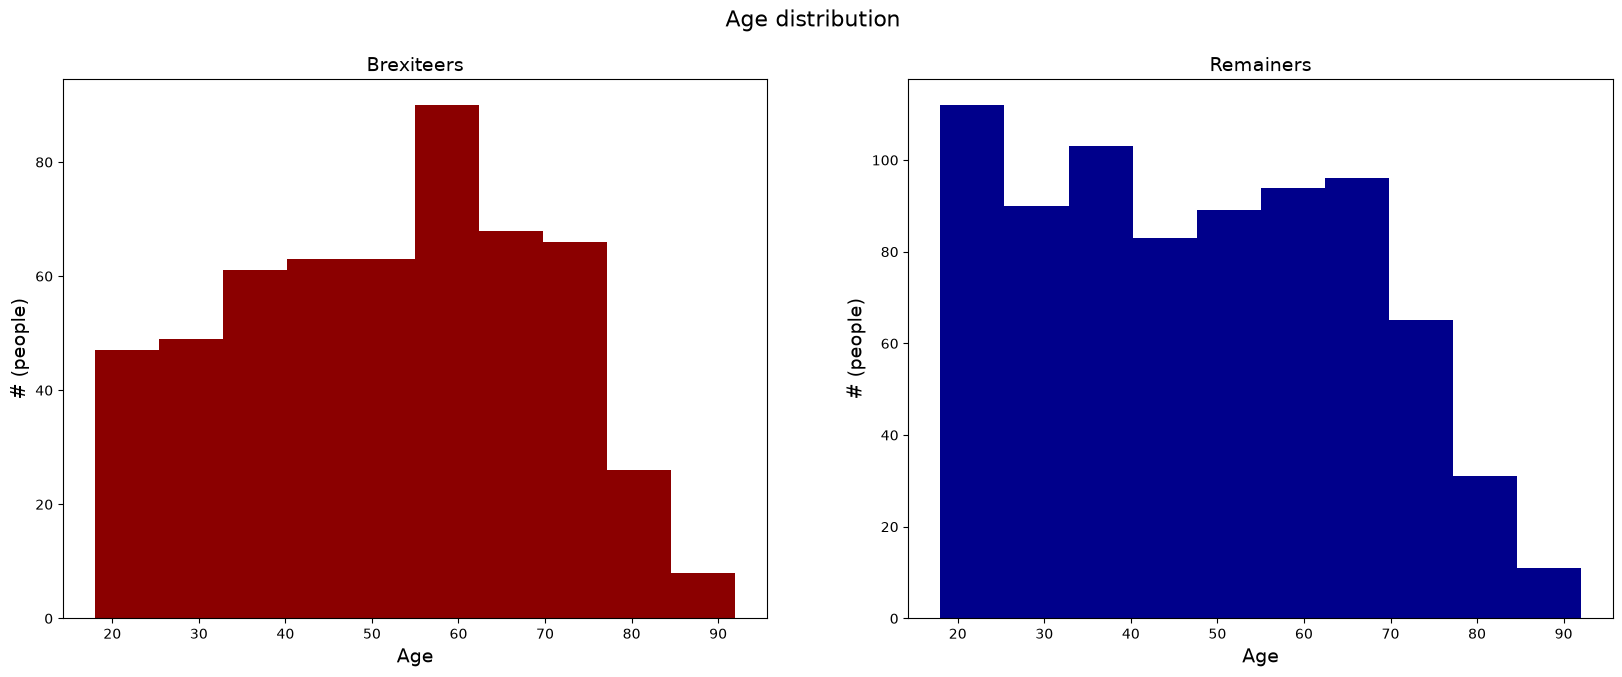

In [12]:
%matplotlib inline
fig, ax = plt.subplots(1,2, figsize=(20,7), sharex=True)
plt.suptitle("Age distribution", fontsize=16)
ax[0].set_title(f"Brexiteers", fontsize=14)
ax[0].hist(brexiteers['age'], color ='darkred')
ax[0].set_xlabel("Age", fontsize = 14)
ax[0].set_ylabel("# (people)", fontsize = 14)

ax[1].set_title(f"Remainers", fontsize=14)
ax[1].hist(remainers['age'], color ='darkblue')
ax[1].set_xlabel("Age", fontsize = 14)
ax[1].set_ylabel("# (people)", fontsize = 14)

Let's compute now the averages and compare them, using another well-known python package:

In [13]:
import numpy as np

avg_brex = np.mean(brexiteers['age'])
avg_rem = np.mean(remainers['age'])
T_obs = avg_brex - avg_rem
print(f"Observed mean age difference (Brexiteers - Remainers): {T_obs:.3f} years")

Observed mean age difference (Brexiteers - Remainers): 3.700 years


### Worked example — One-sided permutation test

How unusual is the observed mean age difference under the exchangeability assumption?

The idea is simple:
- Randomly permute the labels, preserving the group sizes.
- Compute the mean age difference for each permutation.
- Count differences **at least as large as** the observed difference: `T_perm >= T_obs`.

Each permuted dataset has `n_brexiteers` ages in Group B and `n_remainers` ages in Group R. Shuffling the pooled ages and splitting at `n_brexiteers` is equivalent to permuting their labels.

In [14]:
pooled_ages = np.concatenate((brexiteers['age'], remainers['age']))
print(f'Pooled sample size: {len(pooled_ages)}')

Pooled sample size: 1315


Use a fixed random seed to make the permutations reproducible.

In [15]:
np.random.seed(123)

Generate 10,000 permutations and count those with a mean difference at least as large as the observed difference.

In [16]:
n_permutations = 10_000
count = 0
for _ in range(n_permutations):
    shuffled = np.random.permutation(pooled_ages)
    shuffled_b = shuffled[:n_brexiteers]
    shuffled_r = shuffled[n_brexiteers:]
    T_perm = np.mean(shuffled_b) - np.mean(shuffled_r)
    if T_perm >= T_obs:
        count += 1
p_value = (count + 1) / (n_permutations + 1)

The Monte Carlo estimate is $p=(\mathrm{count}+1)/(n_{\mathrm{permutations}}+1)$. The correction includes the observed arrangement and avoids reporting zero. The p-value estimates the probability, under the permutation null, of a statistic at least as large as $T_{\mathrm{obs}}$; it is not the probability that $H_0$ is true.

In [17]:
print(f"Permutations with T_perm >= T_obs: {count} / {n_permutations}")
print(f"One-sided Monte Carlo p-value: {p_value:.6f}")
print("Reject H0 at the 5% level." if p_value < 0.05 else "Do not reject H0 at the 5% level.")

Permutations with T_perm >= T_obs: 0 / 10000
One-sided Monte Carlo p-value: 0.000100
Reject H0 at the 5% level.


A small p-value provides evidence for a higher population mean age among Brexiteers under the test assumptions. It does not establish a causal effect of age on voting.

### Bootstrap resampling

**Bootstrap** is a resampling strategy with replacement. It approximates the sampling distribution of a statistic by repeatedly drawing samples from the observed data, each of the original sample size.

It does not require a specified parametric distribution, but its accuracy still depends on the sample representing the population and on the sampling assumptions (here, independent observations). We will use it to estimate confidence intervals and the variance of an estimator.

### Exercise 1 — Compute sample medians

With one observed sample per group, how can we estimate uncertainty in the population median ages of Brexiteers and Remainers?

Let's recall the dataset and isolate the age feature.

To do so we take a single column of the dataset, which is an object called `Series`, and turn it into a `numpy.ndarray` using `pd.Series.to_numpy`

In [18]:
brexit_ages = pd.Series.to_numpy(brexiteers['age'])
remain_ages = pd.Series.to_numpy(remainers['age'])

First of all we compute the median for the two groups.

Implement `median_value(array)` by sorting a copy of the input and handling odd and even sample sizes. Do not use `np.median` inside your function. Then print the sample median age of each group.

In [21]:
# TODO: Implement median_value without np.median, handling odd and even lengths.
def median_value(array):
    array_cp = array.copy()
    array_cp.sort()
    return array_cp[len(array_cp) // 2]
# YOUR CODE HERE

In [27]:
# TODO: Print both sample median ages using your function.
print(median_value(brexit_ages))
print(median_value(remain_ages))
# YOUR CODE HERE

53
47


Check your results against `np.median` after completing your function.

In [28]:
# TODO: Check both results using np.median.
print(np.median(brexit_ages))
print(np.median(remain_ages))
# YOUR CODE HERE

53.0
47.0


Now we use **bootstrap**: we repeatedly sample the two groups with replacement with the same sample size

First, we use Brexiteers as a worked example with 10,000 bootstrap repetitions.

In [29]:
n = len(brexit_ages)
reps = 10_000

We then use 

```
np.random.choice(a, size=None, replace=True, p=None)
```

which generates a random sample of a certain size from a given 1-D array `a`. If `replace=True`, then a value of `a` can be selected multiple times.

In [30]:
np.random.seed(123)
boot_brexit = np.random.choice(brexit_ages, (reps, n), replace=True)
boot_brexit_medians = np.median(boot_brexit, axis=1)

The results look like this

In [31]:
boot_brexit[:5]

array([[54, 52, 83, ..., 28, 37, 60],
       [64, 70, 42, ..., 55, 33, 38],
       [50, 78, 64, ..., 35, 65, 62],
       [65, 59, 46, ..., 52, 57, 64],
       [54, 72, 61, ..., 84, 24, 35]], shape=(5, 541))

In [32]:
boot_brexit_medians[:5]

array([55., 53., 53., 54., 54.])

The original sample median estimates the **population median**. The bootstrap medians form a **bootstrap distribution**, approximating how the sample median varies across samples. Its standard deviation estimates the standard error of the sample median.

In [33]:
print(f"Mean of the bootstrap medians: {boot_brexit_medians.mean():.3f} years")

Mean of the bootstrap medians: 53.334 years


In [34]:
print(f"Bootstrap standard error of the sample median: {boot_brexit_medians.std(ddof=1):.3f} years")

Bootstrap standard error of the sample median: 1.213 years


Use the 2.5th and 97.5th percentiles of the bootstrap distribution to construct an **approximate 95% bootstrap confidence interval for the population median age**. The 95% confidence level describes approximate coverage over repeated samples, not a probability assigned to the fixed population median.

In [35]:
boot_brexit_median_CI = np.percentile(boot_brexit_medians, [2.5,97.5])
print(f"The C.I. for the median age of brexiteers computed with bootstrap is [{boot_brexit_median_CI[0]},{boot_brexit_median_CI[1]}] ")

The C.I. for the median age of brexiteers computed with bootstrap is [51.0,55.0] 


### Exercise 2 — Bootstrap the Remainer median

Draw `reps` bootstrap samples of size `len(remain_ages)` with replacement. Store their medians in `boot_remain_medians`. Report their mean and standard deviation (the estimated standard error), and store the approximate 95% percentile interval in `boot_remain_median_CI`.

In [36]:
# TODO: Resample Remainer ages and store boot_remain_medians.
boot_remain = np.random.choice(remain_ages, (reps, n), replace=True)
boot_remain_medians = np.median(boot_remain, axis=1)
# YOUR CODE HERE

In [38]:
# TODO: Report bootstrap mean, standard error and boot_remain_median_CI.
print(f"Mean of the bootstrap medians: {boot_remain_medians.mean():.3f} years")
print(f"Bootstrap standard error of the sample median: {boot_remain_medians.std(ddof=1):.3f} years")
boot_remain_median_CI = np.percentile(boot_remain_medians, [2.5,97.5])
print(f"The C.I. for the median age of brexiteers computed with bootstrap is [{boot_remain_median_CI[0]},{boot_remain_median_CI[1]}] ")
# YOUR CODE HERE

Mean of the bootstrap medians: 47.553 years
Bootstrap standard error of the sample median: 1.769 years
The C.I. for the median age of brexiteers computed with bootstrap is [45.0,51.0] 


The following plotting code compares the bootstrap distributions and their approximate 95% confidence intervals once you have completed Exercise 2.

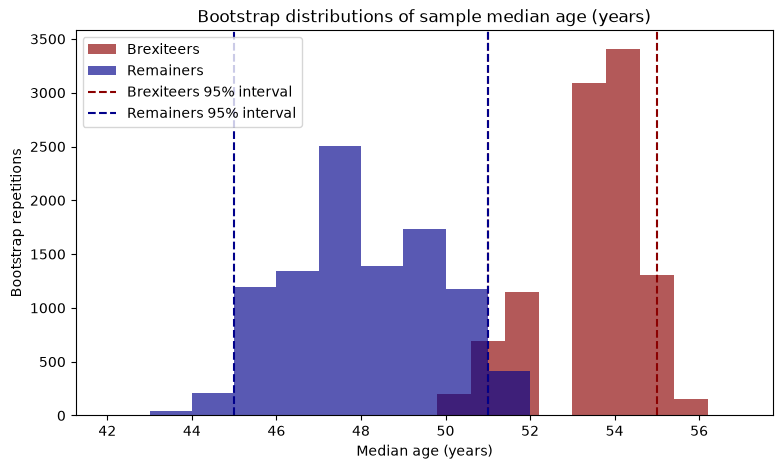

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(boot_brexit_medians, alpha=0.65, color='darkred', label='Brexiteers')
ax.hist(boot_remain_medians, alpha=0.65, color='darkblue', label='Remainers')
for index, bound in enumerate(boot_brexit_median_CI):
    ax.axvline(bound, color='darkred', linestyle='--', label='Brexiteers 95% interval' if index == 0 else None)
for index, bound in enumerate(boot_remain_median_CI):
    ax.axvline(bound, color='darkblue', linestyle='--', label='Remainers 95% interval' if index == 0 else None)
ax.set(title='Bootstrap distributions of sample median age (years)', xlabel='Median age (years)', ylabel='Bootstrap repetitions')
ax.legend();

Compare the interval locations and widths. Interval overlap alone is not a calibrated test of the difference between the population medians.



## Part 2 — Your turn: Titanic

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of the majority of passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

**The data set:**

Load the local file `titanic.csv`, included alongside this notebook. Source: [Data Science Dojo Titanic dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv).

Apply the methods from Part 1. For each inferential result, state which population quantity you are estimating or testing.

### Age and ticket fares

### Exercise 3 — Load and inspect the data

- Import `titanic.csv` using `pd.read_csv` and display its first rows.
- How many columns are there? Here we count all columns, including identifiers and the survival outcome.

In [47]:
# TODO: Load titanic.csv, display the first rows and report the number of columns.

data_titanic_raw = pd.read_csv('titanic.csv')
data_titanic_raw.head()
# data_titanic_raw.describe()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Using `.head()` we know that we have 12 columns

### Exercise 4 — Clean age data and estimate survival

- Select `Age` and `Survived`.
- Remove rows with missing values in these columns using `dropna(how="any")`.
- Compute the percentage of survivors in this cleaned subset, an estimate of $P(Survived=1)$ among passengers with recorded ages.

In [50]:
# TODO: Clean Age/Survived, create both groups and report the survival percentage.

data_titanic = data_titanic_raw[['Age', 'Survived']]
data_titanic = data_titanic.dropna(how="any")
survivors = data_titanic[data_titanic['Survived'] == 1]
death = data_titanic[data_titanic['Survived'] == 0]
n_survivors = len(survivors)
n_death = len(death)
print(f"Percentage of survivors: {n_survivors / (n_survivors + n_death):.1%}")

Percentage of survivors: 40.6%


### Exercise 5 — Compare age distributions

- Plot age histograms for survivors and non-survivors using common bins.
- Compute the difference in average ages (survivors minus non-survivors).

Text(0, 0.5, '# (people)')

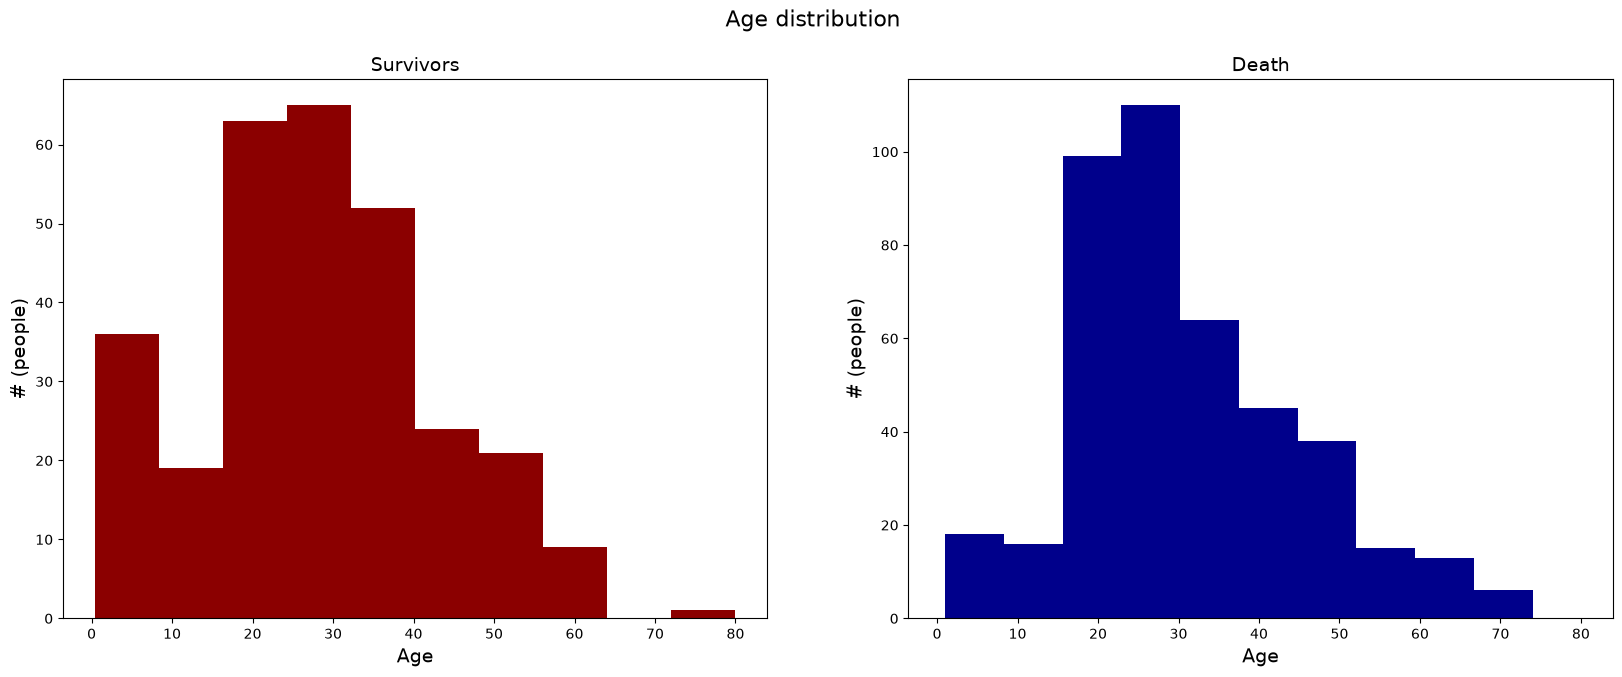

In [52]:
# TODO: Plot labelled age histograms and compute survivors minus non-survivors mean age.

%matplotlib inline
fig, ax = plt.subplots(1,2, figsize=(20,7), sharex=True)
plt.suptitle("Age distribution", fontsize=16)
ax[0].set_title(f"Survivors", fontsize=14)
ax[0].hist(survivors['Age'], color ='darkred')
ax[0].set_xlabel("Age", fontsize = 14)
ax[0].set_ylabel("# (people)", fontsize = 14)

ax[1].set_title(f"Death", fontsize=14)
ax[1].hist(death['Age'], color ='darkblue')
ax[1].set_xlabel("Age", fontsize = 14)
ax[1].set_ylabel("# (people)", fontsize = 14)

In [62]:
avg_survivors = np.mean(survivors['Age'])
avg_death = np.mean(death['Age'])
T_obs_titanic = avg_survivors - avg_death
print(f"Observed mean age difference (survivors - non-survivors): {T_obs_titanic:.3f} years")

Observed mean age difference (survivors - non-survivors): -2.282 years


### Exercise 6 — Compare mean fares

- Starting from the full Titanic dataset, select `Fare` and `Survived` and remove missing values in these columns. Keep zero fares, which are recorded values.
- Form survivor and non-survivor groups and compute their mean fare difference (survivors minus non-survivors).

In [70]:
# TODO: Clean Fare/Survived from the full data, form fare groups and compute their mean difference.

data_titanic_fare = data_titanic_raw[['Fare', 'Survived']]
data_titanic_fare = data_titanic_fare.dropna(how="any")

survivors_fare = data_titanic_fare[data_titanic_fare['Survived'] == 1]
death_fare = data_titanic_fare[data_titanic_fare['Survived'] == 0]

T_obs_fare = survivors_fare["Fare"].mean() - death_fare["Fare"].mean()
print("Survivors average fare: ", survivors_fare["Fare"].mean())
print("Dead average fare: ", death_fare["Fare"].mean())
print("Fare difference (survivors - non-survivors): ", T_obs_fare)

Survivors average fare:  48.39540760233918
Dead average fare:  22.117886885245902
Fare difference (survivors - non-survivors):  26.27752071709328


### Exercise 7 — Permutation test for mean fares

Use 50,000 permutations to test $H_0: \mu_S=\mu_N$ against the one-sided alternative $H_1: \mu_S>\mu_N$, where $S$ denotes survivors and $N$ non-survivors. Assume survival labels are exchangeable with respect to fare under the null.

Use $T_{\mathrm{obs}}=\operatorname{mean}(S)-\operatorname{mean}(N)$, preserve the original group sizes, count `T_perm >= T_obs`, and compute `(count + 1) / (n_permutations + 1)`. Report and interpret the p-value at the 5% level.

In [71]:
# TODO: Run the one-sided fare permutation test and interpret its corrected p-value.
pooled_fare = np.concatenate((survivors_fare['Fare'], death_fare['Fare']))
n_survivors = len(survivors_fare)
n_permutations = 50_000

count = 0
for _ in range(n_permutations):
    shuffled = np.random.permutation(pooled_fare)
    shuffled_b = shuffled[:n_survivors]
    shuffled_r = shuffled[n_survivors:]
    T_perm = np.mean(shuffled_b) - np.mean(shuffled_r)
    if T_perm >= T_obs_fare:
        count += 1
p_value = (count + 1) / (n_permutations + 1)

In [72]:
print(f"Permutations with T_perm >= T_obs: {count} / {n_permutations}")
print(f"One-sided Monte Carlo p-value: {p_value:.6f}")
print("Reject H0 at the 5% level." if p_value < 0.05 else "Do not reject H0 at the 5% level.")

Permutations with T_perm >= T_obs: 0 / 50000
One-sided Monte Carlo p-value: 0.000020
Reject H0 at the 5% level.


Interpret this as an association between fare and survival, without claiming a causal effect.

The permutation test provides evidence of an association between fare and survival on the Titanic. In the sample, survivors tended to have higher fares than passengers who died.

### Exercise 8 — Sample median fares

Compute and report the sample median fare for survivors and non-survivors.

In [77]:
# TODO: Report the sample median fare in each survival group.

survivors_fares = pd.Series.to_numpy(survivors_fare["Fare"])
death_fares = pd.Series.to_numpy(death_fare["Fare"])

print("Survivors median fares:", median_value(survivors_fares))
print("Non-survivors median fares:", median_value(death_fares))

Survivors median fares: 26.0
Non-survivors median fares: 10.5


### Exercise 9 — Bootstrap confidence intervals for median fares

- For each group, draw 10,000 bootstrap samples with replacement, each of the original group size, using `np.random.choice`.
- Compute each resample's median.
- Use `np.percentile` to compute an approximate 95% bootstrap confidence interval for each population median fare.

In [82]:
# TODO: Bootstrap both median fares and compute their approximate 95% percentile intervals.

boot_survivors = np.random.choice(survivors_fares, (reps, n_survivors), replace=True)
boot_survivors_medians = np.median(boot_survivors, axis=1)

print(f"Mean of the bootstrap medians: {boot_survivors_medians.mean():.3f}")
print(f"Bootstrap standard error of the sample median: {boot_survivors_medians.std(ddof=1):.3f}")

boot_survivors_median_CI = np.percentile(boot_survivors_medians, [2.5,97.5])
print(f"The C.I. for the median fare of survivors computed with bootstrap is [{boot_survivors_median_CI[0]},{boot_survivors_median_CI[1]}] ")

Mean of the bootstrap medians: 25.764
Bootstrap standard error of the sample median: 1.000
The C.I. for the median fare of survivors computed with bootstrap is [23.0,26.55] 


In [84]:
# TODO: Bootstrap both median fares and compute their approximate 95% percentile intervals.
n_death = len(death_fare)

boot_death = np.random.choice(death_fares, (reps, n_death), replace=True)
boot_death_medians = np.median(boot_death, axis=1)

print(f"Mean of the bootstrap medians: {boot_death_medians.mean():.3f}")
print(f"Bootstrap standard error of the sample median: {boot_death_medians.std(ddof=1):.3f}")

boot_death_median_CI = np.percentile(boot_death_medians, [2.5,97.5])
print(f"The C.I. for the median fare of non-survivors computed with bootstrap is [{boot_death_median_CI[0]},{boot_death_median_CI[1]}] ")

Mean of the bootstrap medians: 10.399
Bootstrap standard error of the sample median: 0.838
The C.I. for the median fare of non-survivors computed with bootstrap is [9.2167,13.0] 


### Exercise 10 — Visualize and interpret bootstrap distributions

- Plot the bootstrap median fare distributions, including their approximate 95% confidence intervals.
- Compare the locations and widths. What do they suggest about the population median fares?

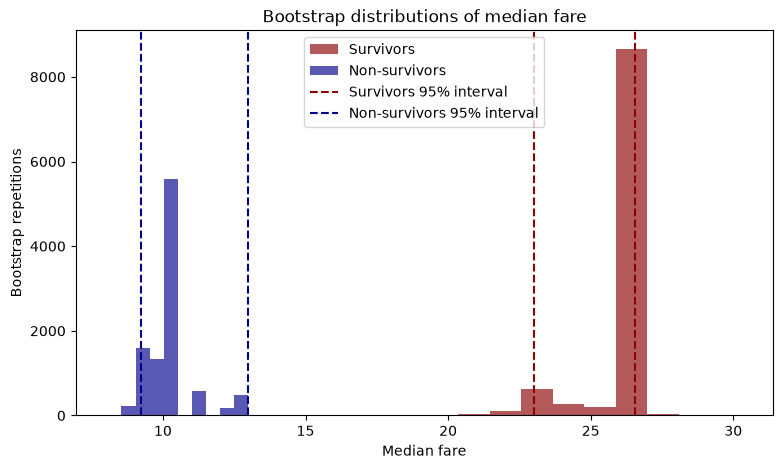

In [85]:
# TODO: Plot both bootstrap distributions with intervals and explain their locations and widths.

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(boot_survivors_medians, alpha=0.65, color='darkred', label='Survivors')
ax.hist(boot_death_medians, alpha=0.65, color='darkblue', label='Non-survivors')
for index, bound in enumerate(boot_survivors_median_CI):
    ax.axvline(bound, color='darkred', linestyle='--', label='Survivors 95% interval' if index == 0 else None)
for index, bound in enumerate(boot_death_median_CI):
    ax.axvline(bound, color='darkblue', linestyle='--', label='Non-survivors 95% interval' if index == 0 else None)
ax.set(title='Bootstrap distributions of median fare', xlabel='Median fare', ylabel='Bootstrap repetitions')
ax.legend();

The obtained bootstrap distributions for survivors and non-survivors are well seperated, suggesting that the median fare of survivors is higher than the median fare if non-survivors

### Exercise 11 — Bootstrap variance of median estimators

Estimate the sampling variance of each sample median fare using the variance of its bootstrap medians. Distinguish this from the variance of individual passenger fares.

In [88]:
# TODO: Estimate both median estimators' sampling variances from the bootstrap medians.
boot_survivors_variance = np.var(boot_survivors_medians, ddof=1)
print(f"Estimated sampling variance of median fare of survivors: {boot_survivors_variance:.3f}")

boot_death_variance = np.var(boot_death_medians, ddof=1)
print(f"Estimated sampling variance of median fare of non-survivors: {boot_death_variance:.3f}")

Estimated sampling variance of median fare of survivors: 1.000
Estimated sampling variance of median fare of non-survivors: 0.702


### Other features associated with survival

Now examine survival rates by **Sex** and **Pclass** (passenger class, with values 1, 2 and 3).

### Exercise 12 — Survival conditional on sex

Estimate $P(Survived=1\mid Sex=\mathrm{female})$ and $P(Survived=1\mid Sex=\mathrm{male})$ from the full dataset, dropping missing values only in the relevant columns.

In [95]:
# TODO: Estimate survival probabilities conditional on each recorded sex.

data_gender = data_titanic_raw[["Sex", "Survived"]].dropna()
survivors_gender = data_gender[data_gender["Survived"] == 1]

male_survivors = survivors_gender[survivors_gender["Sex"] == "male"]
female_survivors = survivors_gender[survivors_gender["Sex"] == "female"]

p_female = len(female_survivors) / len(data_gender[data_gender["Sex"] == "female"]) 
p_male = len(male_survivors) / len(data_gender[data_gender["Sex"] == "male"]) 
print("P(Survived=1 | Sex=female) =", p_female) 
print("P(Survived=1 | Sex=male) =", p_male)


P(Survived=1 | Sex=female) = 0.7420382165605095
P(Survived=1 | Sex=male) = 0.18890814558058924


### Exercise 13 — Survival conditional on sex and passenger class

- Estimate $P(Survived=1\mid Sex=\mathrm{male}, Pclass=c)$ for each $c\in\{1,2,3\}$.
- Identify the classes with the highest and lowest observed survival rates among men.
- Compare these two groups using 10,000 permutations of the binary survival outcomes, preserving group sizes. For this pair, use $H_0:p_A=p_B$, $H_1:p_A>p_B$, and $T_{\mathrm{obs}}=\operatorname{mean}(A)-\operatorname{mean}(B)$, where A is the group with the higher observed rate. Under the null, assume outcomes are exchangeable between the two classes. Count `T_perm >= T_obs` and use the corrected Monte Carlo p-value.
- Report and interpret the result.

Because the pair and direction are selected after looking at the data, this simple pairwise p-value is **exploratory**; it does not account for that selection. A confirmatory comparison should specify the pair and direction in advance.

In [96]:
# TODO: Compute male survival by class, identify the extremes and run and interpret the exploratory permutation test.

data_gender_class = data_titanic_raw[["Sex", "Pclass", "Survived"]].dropna()

survivors_gender_class = data_gender_class[
    data_gender_class["Survived"] == 1
]

male_survivors = survivors_gender_class[
    survivors_gender_class["Sex"] == "male"
]

male_survivors_class1 = male_survivors[
    male_survivors["Pclass"] == 1
]

male_survivors_class2 = male_survivors[
    male_survivors["Pclass"] == 2
]

male_survivors_class3 = male_survivors[
    male_survivors["Pclass"] == 3
]

# Calculate conditional probabilities
p_male_class1 = len(male_survivors_class1) / len(
    data_gender_class[
        (data_gender_class["Sex"] == "male") &
        (data_gender_class["Pclass"] == 1)
    ]
)

p_male_class2 = len(male_survivors_class2) / len(
    data_gender_class[
        (data_gender_class["Sex"] == "male") &
        (data_gender_class["Pclass"] == 2)
    ]
)

p_male_class3 = len(male_survivors_class3) / len(
    data_gender_class[
        (data_gender_class["Sex"] == "male") &
        (data_gender_class["Pclass"] == 3)
    ]
)

print("P(Survived=1 | Sex=male, Pclass=1) =", p_male_class1)
print("P(Survived=1 | Sex=male, Pclass=2) =", p_male_class2)
print("P(Survived=1 | Sex=male, Pclass=3) =", p_male_class3)


P(Survived=1 | Sex=male, Pclass=1) = 0.36885245901639346
P(Survived=1 | Sex=male, Pclass=2) = 0.1574074074074074
P(Survived=1 | Sex=male, Pclass=3) = 0.13544668587896252


It suggests that male passengers from class 1 had a higher survival rate (36%), while class 3 passegers had the lowest survival rate (13.5%)

In [ ]:
male_data = data_gender_class[data_gender_class["Sex"] == "male"]

class1_male = male_data[male_data["Pclass"] == 1]["Survived"]
class3_male = male_data[male_data["Pclass"] == 3]["Survived"]

# Class 1 has the higher observed survival rate
A = class1_male
B = class3_male

T_obs = np.mean(A) - np.mean(B)

pooled_survived = np.concatenate((A, B))

n_A = len(A)

n_permutations = 10_000

count = 0

for _ in range(n_permutations):

    shuffled = np.random.permutation(pooled_survived)

    shuffled_A = shuffled[:n_A]

    shuffled_B = shuffled[n_A:]

    T_perm = np.mean(shuffled_A) - np.mean(shuffled_B)

    if T_perm >= T_obs:
        count += 1

p_value = (count + 1) / (n_permutations + 1)

print("T_obs =", T_obs)
print("count =", count)
print("p-value =", p_value)

print(f"Permutations with T_perm >= T_obs: {count} / {n_permutations}")
print(f"One-sided Monte Carlo p-value: {p_value:.6f}")
print("Reject H0 at the 5% level." if p_value < 0.05 else "Do not reject H0 at the 5% level.")


T_obs = 0.23340577313743094
count = 0
p-value = 9.999000099990002e-05
Permutations with T_perm >= T_obs: 0 / 10000
One-sided Monte Carlo p-value: 0.000100
Reject H0 at the 5% level.


It suggests that class 1 passengers had statistically a higher survival rate than class 3 passengers